In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/supplychain/SupplyChain_Description.csv
/kaggle/input/supplychain/SupplyChain.csv


In [2]:
!ls /kaggle

input  lib  src  working


In [3]:
input = '/kaggle/input/supplychain/'
output = '/kaggle/working/'

In [4]:
## 基础工具
import numpy as np
import pandas as pd
import warnings
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import jn
from IPython.display import display, clear_output
import time

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif']=[u'simHei']
%matplotlib inline

## 数据处理的
import pandas_profiling as pp
#缺失值可视化工具
import missingno as msno

## 模型预测的
import sklearn
from sklearn import linear_model
from sklearn import preprocessing
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier

## 数据降维处理的
from sklearn.decomposition import PCA,FastICA,FactorAnalysis,SparsePCA

import lightgbm as lgb
import xgboost as xgb

## 参数搜索和评价的
from sklearn.model_selection import GridSearchCV,cross_val_score,StratifiedKFold,train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
from sklearn.pipeline import Pipeline

In [5]:
#数据加载
dataset=pd.read_csv(input+'SupplyChain.csv', encoding='unicode_escape')
dataset

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [6]:
data = dataset.copy()

In [7]:
# 18万比订单，53个特征
print(data.shape)
temp = data.isnull().sum()
temp[temp>0]

(180519, 53)


Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64

In [8]:
data['Customer Lname'].value_counts() #Smith        64104
data['Customer Lname'].fillna(data['Customer Lname'].mode()[0], inplace=True)

In [9]:
data['Customer Zipcode'].value_counts()
data['Customer Zipcode'].fillna(data['Customer Zipcode'].mode()[0], inplace=True)

In [10]:
data.select_dtypes(exclude=[object]).columns 

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id',
       'Latitude', 'Longitude', 'Order Customer Id', 'Order Id',
       'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Zipcode',
       'Product Card Id', 'Product Category Id', 'Product Description',
       'Product Price', 'Product Status'],
      dtype='object')

In [11]:
#将Firs tName 与LastName进行合并=>Full Name 
data['Customer Full Name'] = data['Customer Fname'] + data['Customer Lname']
data[['Customer Full Name', 'Customer Fname', 'Customer Lname']]

,Customer Full Name,Customer Fname,Customer Lname
0,CallyHolloway,Cally,Holloway
1,IreneLuna,Irene,Luna
2,GillianMaldonado,Gillian,Maldonado
3,TanaTate,Tana,Tate
4,OrliHendricks,Orli,Hendricks
...,...,...,...
180514,MariaPeterson,Maria,Peterson
180515,RonaldClark,Ronald,Clark
180516,JohnSmith,John,Smith
180517,MarySmith,Mary,Smith


In [12]:

# df = dataset['Customer State'].astype('category').copy()  # Categorize!
# df

# 选择需要处理的object columns
# dataset.select_dtypes(include=[object]).columns  
# dataset.select_dtypes(exclude=[object]).columns  

# 转换格式 data['Customer State'].astype('category')
astype_columns = ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Lname', 
                  'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Customer Full Name',
                  'Order City', 'Order Country', 'Order Region', 'Order State',
                  'Product Name', 'Shipping Mode', 'shipping date (DateOrders)', 'order date (DateOrders)', 'Order Status'
                 ]

# drop
drop_columns = ['Customer Email', 'Customer Password', 'Product Image',  'Order Zipcode', 'Product Description']

# 特征梳理
# 时间日期多维度： order date (DateOrders)   shipping date (DateOrders)
# 补全缺失值后：Customer Fname + Customer Lname = Customer Full Name
feature_columns = ['order date (DateOrders)', 'shipping date (DateOrders)']

# y值
y_column = ['Order Status']



In [13]:
data.drop(drop_columns, axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [14]:
#  order date (DateOrders)
#按照不同的时间维度（年，月，星期，小时）的趋势
#data[['order date (DateOrders)']]
#创建时间影索引
temp = pd.DatetimeIndex(data['order date (DateOrders)'])
temp

DatetimeIndex(['2018-01-31 22:56:00', '2018-01-13 12:27:00',
               '2018-01-13 12:06:00', '2018-01-13 11:45:00',
               '2018-01-13 11:24:00', '2018-01-13 11:03:00',
               '2018-01-13 10:42:00', '2018-01-13 10:21:00',
               '2018-01-13 10:00:00', '2018-01-13 09:39:00',
               ...
               '2016-01-16 06:49:00', '2016-01-16 06:49:00',
               '2016-01-16 06:28:00', '2016-01-16 06:07:00',
               '2016-01-16 05:04:00', '2016-01-16 03:40:00',
               '2016-01-16 01:34:00', '2016-01-15 21:00:00',
               '2016-01-15 20:18:00', '2016-01-15 18:54:00'],
              dtype='datetime64[ns]', name='order date (DateOrders)', length=180519, freq=None)

In [15]:
# order date (DateOrders) 字段中的时间多尺度 year, month, weekday, hour, month_year
data['order_year'] = temp.year
data['order_month'] = temp.month
data['order_week_day'] = temp.weekday
data['order_hour'] = temp.hour
#data['order_month_year'] = temp.to_period('M')  auto-sklearn unsported
data

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Customer Full Name,order_year,order_month,order_week_day,order_hour
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class,CallyHolloway,2018,1,2,22
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class,IreneLuna,2018,1,5,12
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class,GillianMaldonado,2018,1,5,12
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class,TanaTate,2018,1,5,11
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class,OrliHendricks,2018,1,5,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class,MariaPeterson,2016,1,5,3
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class,RonaldClark,2016,1,5,1
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class,JohnSmith,2016,1,4,21
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class,MarySmith,2016,1,4,20


<AxesSubplot:title={'center':'Average sales in Months'}, xlabel='order_month'>

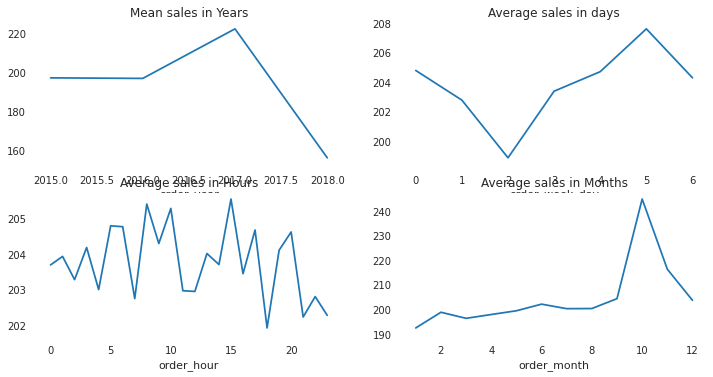

In [16]:
# 对销售额进行探索，按照不同的时间维度（年，月，星期，小时）的趋势
plt.subplot(4, 2, 1)
df_year = data.groupby('order_year')
df_year['Sales'].mean().plot(figsize=(12, 12), title='Mean sales in Years')

plt.subplot(4, 2, 2)
df_day = data.groupby('order_week_day')
df_day['Sales'].mean().plot(figsize=(12,12), title='Average sales in days')

plt.subplot(4, 2, 3)
df_hour = data.groupby('order_hour')
df_hour['Sales'].mean().plot(figsize=(12,12), title='Average sales in Hours')

plt.subplot(4, 2, 4)
df_month = data.groupby('order_month')
df_month['Sales'].mean().plot(figsize=(12, 12), title='Average sales in Months')

In [17]:
#  shipping date (DateOrders)
#按照不同的时间维度（年，月，星期，小时）的趋势
#data[['shipping date (DateOrders)']]
#创建时间影索引
temp = pd.DatetimeIndex(data['shipping date (DateOrders)'])
temp

DatetimeIndex(['2018-02-03 22:56:00', '2018-01-18 12:27:00',
               '2018-01-17 12:06:00', '2018-01-16 11:45:00',
               '2018-01-15 11:24:00', '2018-01-19 11:03:00',
               '2018-01-15 10:42:00', '2018-01-15 10:21:00',
               '2018-01-16 10:00:00', '2018-01-15 09:39:00',
               ...
               '2016-01-19 06:49:00', '2016-01-19 06:49:00',
               '2016-01-18 06:28:00', '2016-01-22 06:07:00',
               '2016-01-19 05:04:00', '2016-01-20 03:40:00',
               '2016-01-19 01:34:00', '2016-01-20 21:00:00',
               '2016-01-18 20:18:00', '2016-01-19 18:54:00'],
              dtype='datetime64[ns]', name='shipping date (DateOrders)', length=180519, freq=None)

In [18]:
# shipping date (DateOrders) 字段中的时间多尺度 year, month, weekday, hour, month_year
data['shipping_year'] = temp.year
data['shipping_month'] = temp.month
data['shipping_week_day'] = temp.weekday
data['shipping_hour'] = temp.hour
# data['shipping_month_year'] = temp.to_period('M')    auto-sklearn unsported
data

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Shipping Mode,Customer Full Name,order_year,order_month,order_week_day,order_hour,shipping_year,shipping_month,shipping_week_day,shipping_hour
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Standard Class,CallyHolloway,2018,1,2,22,2018,2,5,22
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Standard Class,IreneLuna,2018,1,5,12,2018,1,3,12
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Standard Class,GillianMaldonado,2018,1,5,12,2018,1,2,12
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Standard Class,TanaTate,2018,1,5,11,2018,1,1,11
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Standard Class,OrliHendricks,2018,1,5,11,2018,1,0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Standard Class,MariaPeterson,2016,1,5,3,2016,1,2,3
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Second Class,RonaldClark,2016,1,5,1,2016,1,1,1
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Standard Class,JohnSmith,2016,1,4,21,2016,1,2,21
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,Standard Class,MarySmith,2016,1,4,20,2016,1,0,20


In [19]:
for column in astype_columns:
    data[column] = data[column].astype('category')

In [20]:
# 18万比订单，53个特征
print(data.shape)
temp = data.isnull().sum()
temp[temp>0]

(180519, 57)


Series([], dtype: int64)

In [21]:
# data.select_dtypes(include=[object]).columns  
# data.select_dtypes(exclude=[object]).columns  
data.info()
data.select_dtypes(include=[object]).columns  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   Type                           180519 non-null  category
 1   Days for shipping (real)       180519 non-null  int64   
 2   Days for shipment (scheduled)  180519 non-null  int64   
 3   Benefit per order              180519 non-null  float64 
 4   Sales per customer             180519 non-null  float64 
 5   Delivery Status                180519 non-null  category
 6   Late_delivery_risk             180519 non-null  int64   
 7   Category Id                    180519 non-null  int64   
 8   Category Name                  180519 non-null  category
 9   Customer City                  180519 non-null  category
 10  Customer Country               180519 non-null  category
 11  Customer Fname                 180519 non-null  category
 12  Customer Id     

Index([], dtype='object')

In [22]:
# 标签反转演示
display("Order Status", clfs["Order Status"].inverse_transform([0,1,2,3,4,5,6,7,8]))

display("Order Status", clfs["Order Status"].inverse_transform([8]))

NameError: name 'clfs' is not defined

# 对于欺诈订单进行预测，即Order Status='SUSPECTED_FRAUD'

COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: Order Status, dtype: int64

<AxesSubplot:>

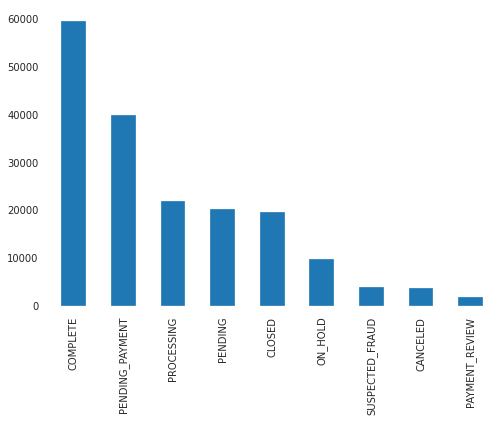

In [23]:
display(data['Order Status'].value_counts())
data['Order Status'].value_counts().plot.bar()

In [24]:
#  批量Labels encoding:

# preprocessing.LabelBinarizer
# preprocessing.LabelEncoder

data2 = data.copy()

str_cols = data2.select_dtypes(include=['category']).columns
clfs = {c:preprocessing.LabelEncoder() for c in str_cols}

for col, clf in clfs.items():
    data2[col] = clfs[col].fit_transform(data2[col])

data2

# 标签反转演示
# for col, clf in clfs.items():
#     display(col, clfs[col].inverse_transform([0]))

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Shipping Mode,Customer Full Name,order_year,order_month,order_week_day,order_hour,shipping_year,shipping_month,shipping_week_day,shipping_hour
0,1,3,4,91.250000,314.640015,0,0,73,40,66,...,3,1876,2018,1,2,22,2018,2,5,22
1,3,5,4,-249.089996,311.359985,1,1,73,40,66,...,3,5378,2018,1,5,12,2018,1,3,12
2,0,4,4,-247.779999,309.720001,3,0,73,40,452,...,3,4429,2018,1,5,12,2018,1,2,12
3,1,3,4,22.860001,304.809998,0,0,73,40,285,...,3,12929,2018,1,5,11,2018,1,1,11
4,2,2,4,134.210007,298.250000,0,0,73,40,66,...,3,10638,2018,1,5,11,2018,1,0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,3,0,45,18,59,...,3,8426,2016,1,5,3,2016,1,2,3
180515,1,3,2,-613.770019,395.980011,1,1,45,18,26,...,2,11679,2016,1,5,1,2016,1,1,1
180516,3,5,4,141.110001,391.980011,1,1,45,18,55,...,3,6300,2016,1,4,21,2016,1,2,21
180517,2,3,4,186.229996,387.980011,0,0,45,18,66,...,3,9384,2016,1,4,20,2016,1,0,20


In [25]:
#  切分训练集、测试集

# # ### 删除不适用的特征
drop_features = ['Order Status', 
                 #'shipping_year', 'shipping_month', 'shipping_week_day', 'shipping_hour',
                 #'order_year', 'order_month', 'order_week_day', 'order_hour',
                 'order date (DateOrders)', 'shipping date (DateOrders)'
                ]
feature_cols = [column for column in data2.columns if column not in drop_features]
# display(feature_cols)

astype_features = [
                   'shipping_year', 'shipping_month', 'shipping_week_day', 'shipping_hour',
                   'order_year', 'order_month', 'order_week_day', 'order_hour'
                  ]

for column in astype_features:
    data[column] = data[column].astype('category')

# # ###随机采样，测试程序用，设置一个小样本的数据集，快速预览模型
# np.random.seed(10)
# 
# #按照百分比抽样，不放回
# data2_sample = data2.sample(frac=0.01) #抽取20%的数据
# display(data2_sample.shape)
# 
# # 样本数据
# X = data2_sample[feature_cols]
# y = data2_sample['Order Status']
# 
# 全量特征
# AC 0.315976069133614
# CPU times: user 3min 24s, sys: 1min 20s, total: 4min 44s
# Wall time: 1min 12s



# 全量数据
X = data2[feature_cols]
y = data2['Order Status']

# 转换为二分类，需要修改模型
# "SUSPECTED_FRAUD" --> 8
# y_2 = y.apply(lambda x : 1 if x == 8 else 0).copy()

X_train, X_test, y_train, y_test = \
        train_test_split(X, y, random_state=2021)

In [26]:
%%time

# GaussianNB
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)
print("Number of mislabeled points out of a total %d points : %d"
      % (X_test.shape[0], (y_test != y_pred).sum()))

# 转换为二分类标签
display( pd.Series(y_test).value_counts() )
y_test_2 = y_test.apply(lambda x : 1 if x ==8 else 0).copy()
y_test_2.value_counts()

# # 转换为二分类标签
display( pd.Series(y_pred).value_counts() )
y_pred_2 = pd.Series(y_pred).apply(lambda x : 1 if x ==8 else 0).copy()
pd.Series(y_pred_2).value_counts()

# 混淆矩阵
m = sklearn.metrics.confusion_matrix(y_test_2, y_pred_2)
print('混淆矩阵为：', m, sep='\n')

# 准确率
print("Accuracy score", accuracy_score(y_test_2, y_pred_2))

Number of mislabeled points out of a total 45130 points : 28826


2    14743
6     9899
7     5538
5     5170
1     4948
3     2394
8     1031
0      910
4      497
Name: Order Status, dtype: int64

2    32213
6    12574
0      233
3       72
7       32
5        3
8        3
dtype: int64

混淆矩阵为：
[[44097     2]
 [ 1030     1]]
Accuracy score 0.9771327276756038
CPU times: user 509 ms, sys: 85.2 ms, total: 595 ms
Wall time: 592 ms


In [27]:
%%time

# LinearSVC
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
clf = make_pipeline(StandardScaler(),
                    LinearSVC(random_state=0, tol=1e-5))
clf.fit(X_train, y_train)

# print(clf.named_steps['linearsvc'].coef_)
# print(clf.named_steps['linearsvc'].intercept_)

y_pred = clf.predict(X_test)

# 转换为二分类标签
display( pd.Series(y_test).value_counts() )
y_test_2 = y_test.apply(lambda x : 1 if x ==8 else 0).copy()
y_test_2.value_counts()

# # 转换为二分类标签
display( pd.Series(y_pred).value_counts() )
y_pred_2 = pd.Series(y_pred).apply(lambda x : 1 if x ==8 else 0).copy()
pd.Series(y_pred_2).value_counts()

# 混淆矩阵
m = sklearn.metrics.confusion_matrix(y_test_2, y_pred_2)
print('混淆矩阵为：', m, sep='\n')

# 准确率
print("Accuracy score", accuracy_score(y_test_2, y_pred_2))

2    14743
6     9899
7     5538
5     5170
1     4948
3     2394
8     1031
0      910
4      497
Name: Order Status, dtype: int64

2    23688
7     9466
1     4948
6     3888
5     2080
8      896
0      164
dtype: int64

混淆矩阵为：
[[43677   422]
 [  557   474]]
Accuracy score 0.9783071127852869
CPU times: user 11min 27s, sys: 533 ms, total: 11min 27s
Wall time: 11min 27s


In [28]:
%%time

# KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)
      
y_pred = neigh.predict(X_test)

# 转换为二分类标签
display( pd.Series(y_test).value_counts() )
y_test_2 = y_test.apply(lambda x : 1 if x ==8 else 0).copy()
y_test_2.value_counts()

# # 转换为二分类标签
display( pd.Series(y_pred).value_counts() )
y_pred_2 = pd.Series(y_pred).apply(lambda x : 1 if x ==8 else 0).copy()
pd.Series(y_pred_2).value_counts()

# 混淆矩阵
m = sklearn.metrics.confusion_matrix(y_test_2, y_pred_2)
print('混淆矩阵为：', m, sep='\n')

# 准确率
print("Accuracy score", accuracy_score(y_test_2, y_pred_2))

2    14743
6     9899
7     5538
5     5170
1     4948
3     2394
8     1031
0      910
4      497
Name: Order Status, dtype: int64

2    15803
6     9418
1     5492
7     4964
5     4738
3     2307
0     1111
8      838
4      459
dtype: int64

混淆矩阵为：
[[43896   203]
 [  396   635]]
Accuracy score 0.9867272324396189
CPU times: user 2min 1s, sys: 57.5 s, total: 2min 58s
Wall time: 1min 39s


In [29]:
%%time 

# LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clf = LinearDiscriminantAnalysis()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# 转换为二分类标签
display( pd.Series(y_test).value_counts() )
y_test_2 = y_test.apply(lambda x : 1 if x ==8 else 0).copy()
y_test_2.value_counts()

# # 转换为二分类标签
display( pd.Series(y_pred).value_counts() )
y_pred_2 = pd.Series(y_pred).apply(lambda x : 1 if x ==8 else 0).copy()
pd.Series(y_pred_2).value_counts()

# 混淆矩阵
m = sklearn.metrics.confusion_matrix(y_test_2, y_pred_2)
print('混淆矩阵为：', m, sep='\n')

# 准确率
print("Accuracy score", accuracy_score(y_test_2, y_pred_2))

2    14743
6     9899
7     5538
5     5170
1     4948
3     2394
8     1031
0      910
4      497
Name: Order Status, dtype: int64

2    44028
8      867
0      232
6        3
dtype: int64

混淆矩阵为：
[[43687   412]
 [  576   455]]
Accuracy score 0.978107688898737
CPU times: user 2.41 s, sys: 504 ms, total: 2.92 s
Wall time: 1.56 s


In [30]:
%%time

# DecisionTreeClassifier
#from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=2021)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 转换为二分类标签
display( pd.Series(y_test).value_counts() )
y_test_2 = y_test.apply(lambda x : 1 if x ==8 else 0).copy()
y_test_2.value_counts()

# # 转换为二分类标签
display( pd.Series(y_pred).value_counts() )
y_pred_2 = pd.Series(y_pred).apply(lambda x : 1 if x ==8 else 0).copy()
pd.Series(y_pred_2).value_counts()

# 混淆矩阵
m = sklearn.metrics.confusion_matrix(y_test_2, y_pred_2)
print('混淆矩阵为：', m, sep='\n')

# 准确率
print("Accuracy score", accuracy_score(y_test_2, y_pred_2))

2    14743
6     9899
7     5538
5     5170
1     4948
3     2394
8     1031
0      910
4      497
Name: Order Status, dtype: int64

2    14675
6     9902
7     5526
5     5182
1     4948
3     2462
8     1045
0      896
4      494
dtype: int64

混淆矩阵为：
[[43991   108]
 [   94   937]]
Accuracy score 0.9955240416574341
CPU times: user 8.71 s, sys: 20.3 ms, total: 8.73 s
Wall time: 8.72 s


In [31]:
%%time

# RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=7, random_state=2021)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# 转换为二分类标签
display( pd.Series(y_test).value_counts() )
y_test_2 = y_test.apply(lambda x : 1 if x ==8 else 0).copy()
y_test_2.value_counts()

# # 转换为二分类标签
display( pd.Series(y_pred).value_counts() )
y_pred_2 = pd.Series(y_pred).apply(lambda x : 1 if x ==8 else 0).copy()
pd.Series(y_pred_2).value_counts()

# 混淆矩阵
m = sklearn.metrics.confusion_matrix(y_test_2, y_pred_2)
print('混淆矩阵为：', m, sep='\n')

# 准确率
print("Accuracy score", accuracy_score(y_test_2, y_pred_2))

2    14743
6     9899
7     5538
5     5170
1     4948
3     2394
8     1031
0      910
4      497
Name: Order Status, dtype: int64

2    21899
6    20214
8     1550
7      837
0      355
1      186
5       89
dtype: int64

混淆矩阵为：
[[43504   595]
 [   76   955]]
Accuracy score 0.9851318413472191
CPU times: user 27.5 s, sys: 19.5 ms, total: 27.5 s
Wall time: 27.5 s


[09:36:01] WARNING: ../src/learner.cc:541: 
Parameters: { colsample_btree, scale_pos_weight } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[09:36:03] WARNING: ../src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


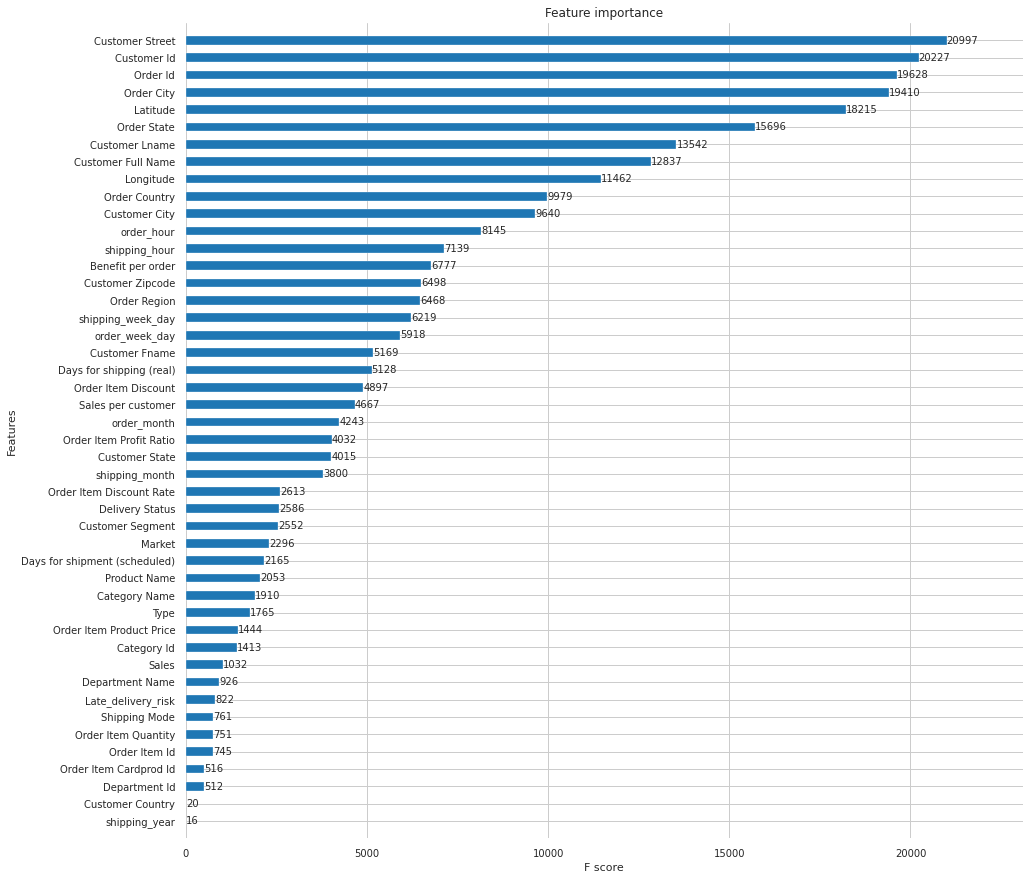

2    14743
6     9899
7     5538
5     5170
1     4948
3     2394
8     1031
0      910
4      497
Name: Order Status, dtype: int64

2    15776
6    10053
7     5705
5     5003
1     4948
3     1361
8     1060
0      881
4      343
dtype: int64

混淆矩阵为：
[[44015    84]
 [   55   976]]
Accuracy score 0.9969200088632838
CPU times: user 1h 53min 28s, sys: 6.35 s, total: 1h 53min 34s
Wall time: 28min 56s


In [32]:
%%time

#XGBClassifier 
xgr = xgb.XGBClassifier(learning_rate=0.1,
                        n_estimators=1000,         # 树的个数--1000棵树建立xgboost
                        max_depth=6,               # 树的深度
                        min_child_weight = 1,      # 叶子节点最小权重
                        gamma=0.,                  # 惩罚项中叶子结点个数前的参数
                        subsample=0.8,             # 随机选择80%样本建立决策树
                        colsample_btree=0.8,       # 随机选择80%特征建立决策树
                        objective='multi:softmax', # 指定损失函数
                        scale_pos_weight=1,        # 解决样本个数不平衡的问题
                        random_state=27            # 随机数
                        )

xgr.fit(X_train, y_train)
y_pred = xgr.predict(X_test)

### plot feature importance
fig,ax = plt.subplots(figsize=(15,15))
xgb.plot_importance(xgr,
                height=0.5,
                ax=ax,
                max_num_features=64)
plt.show()

# 转换为二分类标签
display( pd.Series(y_test).value_counts() )
y_test_2 = y_test.apply(lambda x : 1 if x ==8 else 0).copy()
y_test_2.value_counts()

# # 转换为二分类标签
display( pd.Series(y_pred).value_counts() )
y_pred_2 = pd.Series(y_pred).apply(lambda x : 1 if x ==8 else 0).copy()
pd.Series(y_pred_2).value_counts()

# 混淆矩阵
m = sklearn.metrics.confusion_matrix(y_test_2, y_pred_2)
print('混淆矩阵为：', m, sep='\n')

# 准确率
print("Accuracy score", accuracy_score(y_test_2, y_pred_2))

In [33]:
# %%time

# # 训练
# LR = sklearn.linear_model.LinearRegression()  #报错
# LR = sklearn.linear_model.LogisticRegression(multi_class="multinomial", solver="newton-cg", max_iter=1000)

# 多分类
LR = sklearn.linear_model.LogisticRegression(multi_class="multinomial", solver="newton-cg", max_iter=1000) 

reg = LR.fit(X_train, y_train)
reg.score(X_train, y_train)
reg.coef_
reg.intercept_
y_pred = reg.predict(X_test)

print("LR")
print(classification_report(y_test, y_pred))
print("AC",accuracy_score(y_test, y_pred))


# 转换为二分类标签
display( pd.Series(y_test).value_counts() )
y_test_2 = y_test.apply(lambda x : 1 if x ==8 else 0).copy()
y_test_2.value_counts()

# # 转换为二分类标签
display( pd.Series(y_pred).value_counts() )
y_pred_2 = pd.Series(y_pred).apply(lambda x : 1 if x ==8 else 0).copy()
pd.Series(y_pred_2).value_counts()

# 混淆矩阵
m = sklearn.metrics.confusion_matrix(y_test_2, y_pred_2)
print('混淆矩阵为：', m, sep='\n')

# 准确率
print("Accuracy score", accuracy_score(y_test_2, y_pred_2))

LR
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       910
           1       0.00      0.00      0.00      4948
           2       0.46      1.00      0.63     14743
           3       0.00      0.00      0.00      2394
           4       0.00      0.00      0.00       497
           5       0.00      0.00      0.00      5170
           6       0.01      0.02      0.02      9899
           7       0.50      0.00      0.00      5538
           8       0.00      0.00      0.00      1031

    accuracy                           0.33     45130
   macro avg       0.11      0.11      0.07     45130
weighted avg       0.21      0.33      0.21     45130

AC 0.3309550188344782


2    14743
6     9899
7     5538
5     5170
1     4948
3     2394
8     1031
0      910
4      497
Name: Order Status, dtype: int64

2    32277
6    12851
7        2
dtype: int64

混淆矩阵为：
[[44099     0]
 [ 1031     0]]
Accuracy score 0.9771548858852205


In [34]:
#  模型调优
# 交叉验证，
# 网格搜索

## 分类任务评价指标

In [35]:
# #  精确率
# print(sklearn.metrics.precision_score(y_test_2, y_pred_2, average='macro'))  # 0.2222222222222222
# print(sklearn.metrics.precision_score(y_test_2, y_pred_2, average='micro'))  # 0.3333333333333333
# print(sklearn.metrics.precision_score(y_test_2, y_pred_2, average='weighted'))  # 0.2222222222222222
# print(sklearn.metrics.precision_score(y_test_2, y_pred_2, average=None))

In [36]:
# # 召回率
# print(sklearn.metrics.recall_score(y_test_2, y_pred_2, average='macro'))  # 0.3333333333333333
# print(sklearn.metrics.recall_score(y_test_2, y_pred_2, average='micro'))  # 0.3333333333333333
# print(sklearn.metrics.recall_score(y_test_2, y_pred_2, average='weighted'))  # 0.3333333333333333
# print(sklearn.metrics.recall_score(y_test_2, y_pred_2, average=None))  # [1. 0. 0.]

In [37]:
# # F1 score
# print(sklearn.metrics.f1_score(y_test_2, y_pred_2, average='macro'))  # 0.26666666666666666
# print(sklearn.metrics.f1_score(y_test_2, y_pred_2, average='micro'))  # 0.3333333333333333
# print(sklearn.metrics.f1_score(y_test_2, y_pred_2, average='weighted'))  # 0.26666666666666666
# print(sklearn.metrics.f1_score(y_test_2, y_pred_2, average=None))  # [0.8 0.  0. ]